## **ЗПАД | Лабораторна робота 3**
**Виконав: Пономаренко Роман Володимирович | ФБ-44**

**Здійснити Data Cleaning**

In [ ]:
import pandas as pd
import numpy as np

# Пряме посилання на файл даних
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"

cols = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

df = pd.read_csv(url, names=cols, na_values="?")
print("Розмір до очищення:", df.shape)

mean_losses = df['normalized-losses'].mean()
df['normalized-losses'] = df['normalized-losses'].fillna(mean_losses)
df = df.dropna(subset=['price', 'horsepower', 'num-of-doors', 'bore', 'stroke', 'peak-rpm'])

print("Розмір після очищення:", df.shape)
display(df.head())

Розмір до очищення: (205, 26)
Розмір після очищення: (193, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


**Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).**

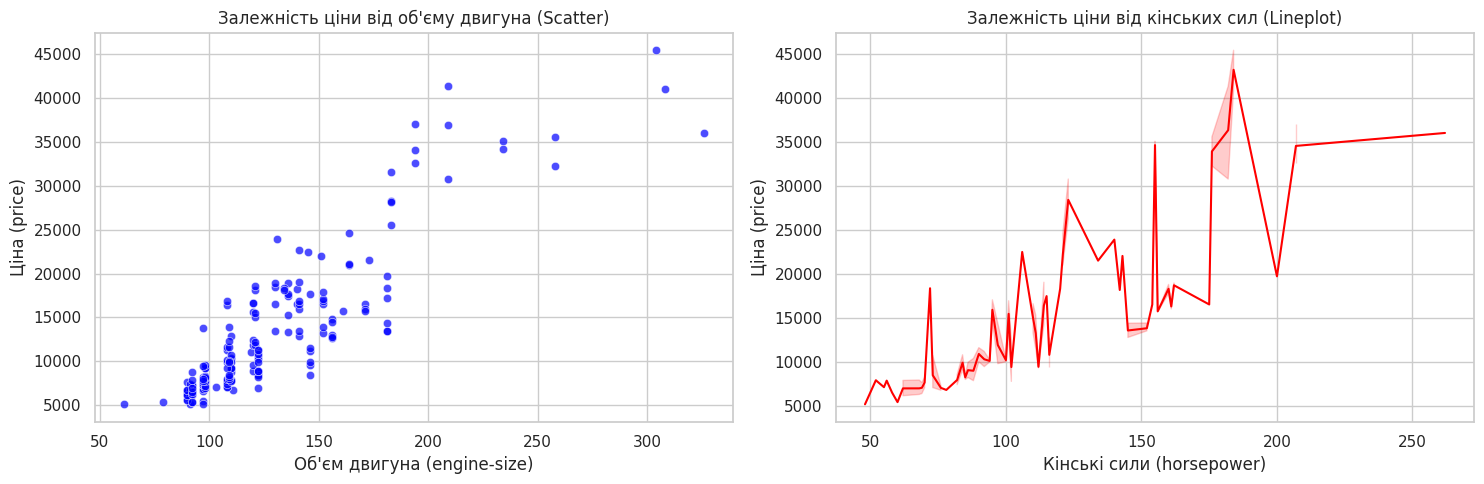

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot: Залежність ціни від об'єму двигуна
sns.scatterplot(data=df, x="engine-size", y="price", ax=axes[0], color="blue", alpha=0.7)
axes[0].set_title("Залежність ціни від об'єму двигуна (Scatter)")
axes[0].set_xlabel("Об'єм двигуна (engine-size)")
axes[0].set_ylabel("Ціна (price)")

# Line plot: Залежність ціни від кінських сил
df_sorted = df.sort_values(by="horsepower")
sns.lineplot(data=df_sorted, x="horsepower", y="price", ax=axes[1], color="red")
axes[1].set_title("Залежність ціни від кінських сил (Lineplot)")
axes[1].set_xlabel("Кінські сили (horsepower)")
axes[1].set_ylabel("Ціна (price)")

plt.tight_layout()
plt.show()

**Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.**

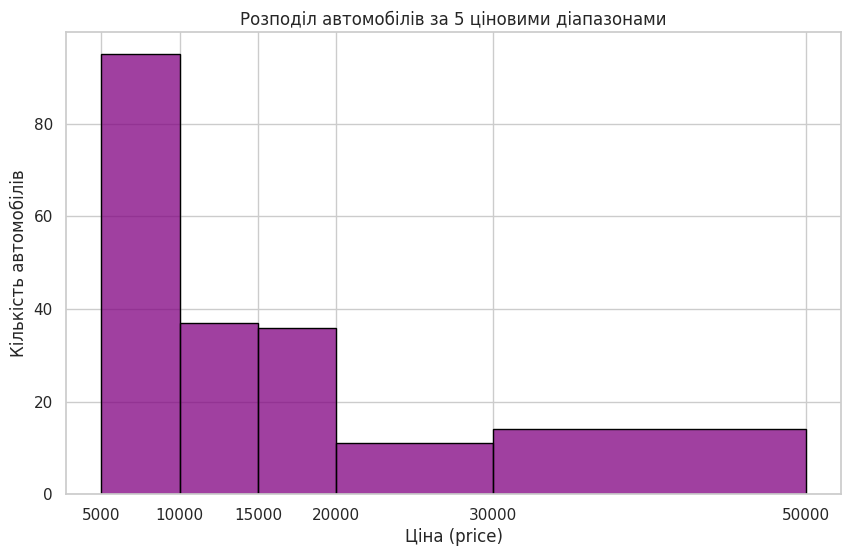

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

custom_bins = [5000, 10000, 15000, 20000, 30000, 50000]

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="price", bins=custom_bins, color="purple", edgecolor="black")

plt.title("Розподіл автомобілів за 5 ціновими діапазонами")
plt.xlabel("Ціна (price)")
plt.ylabel("Кількість автомобілів")

plt.xticks(custom_bins)

plt.show()

**Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57**

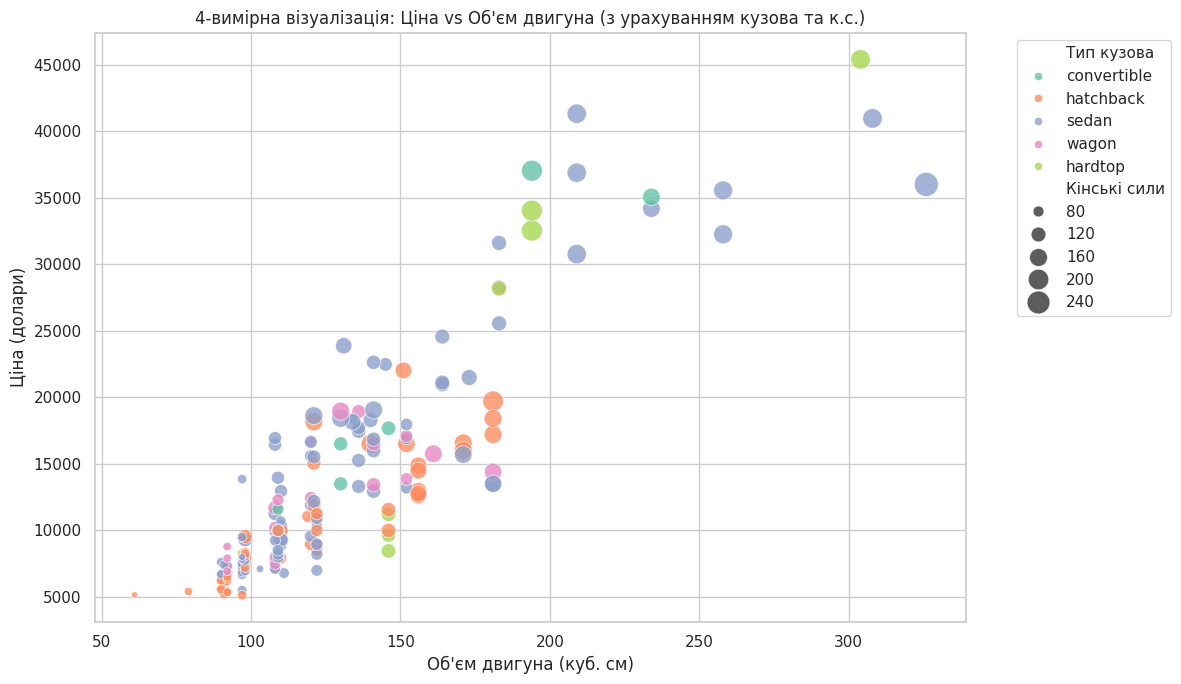

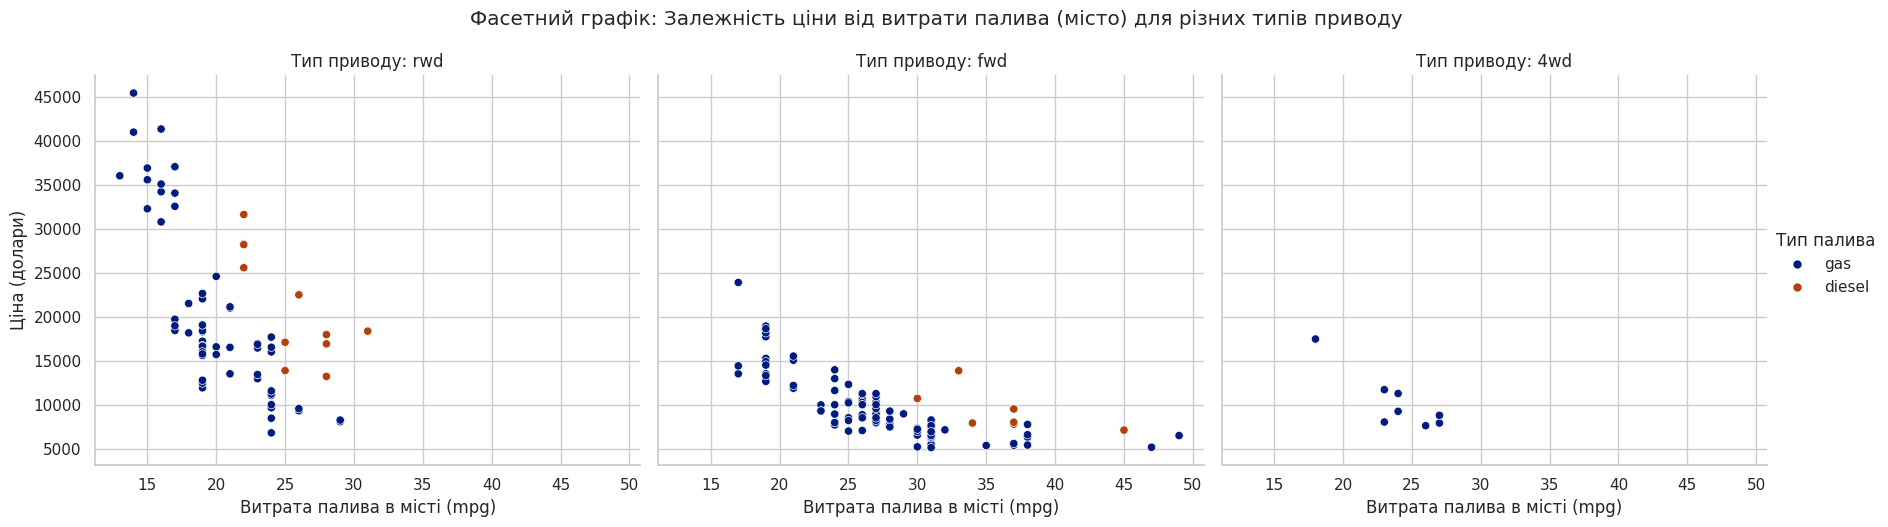

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Багатовимірний Scatter Plot

plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=df, 
    x="engine-size", 
    y="price", 
    hue="body-style",     
    size="horsepower",    
    sizes=(20, 300),      
    alpha=0.8,           
    palette="Set2"
)

plt.title("4-вимірна візуалізація: Ціна vs Об'єм двигуна (з урахуванням кузова та к.с.)")
plt.xlabel("Об'єм двигуна (куб. см)")
plt.ylabel("Ціна (долари)")

# Дістаємо легенду і міняємо в ній системні назви на людські
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for text in legend.texts:
    if text.get_text() == 'body-style':
        text.set_text('Тип кузова')
    elif text.get_text() == 'horsepower':
        text.set_text('Кінські сили')

plt.tight_layout()
plt.show()

# Facet Grid (Фасетні графіки)

g = sns.relplot(
    data=df, 
    x="city-mpg", 
    y="price", 
    col="drive-wheels",   
    hue="fuel-type",      
    kind="scatter",
    height=5, 
    aspect=1.2,
    palette="dark"
)

g.set_axis_labels("Витрата палива в місті (mpg)", "Ціна (долари)")

g.set_titles(col_template="Тип приводу: {col_name}")

if g.legend:
    g.legend.set_title("Тип палива")

g.figure.suptitle("Фасетний графік: Залежність ціни від витрати палива (місто) для різних типів приводу", y=1.05)
plt.show()

**Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.**

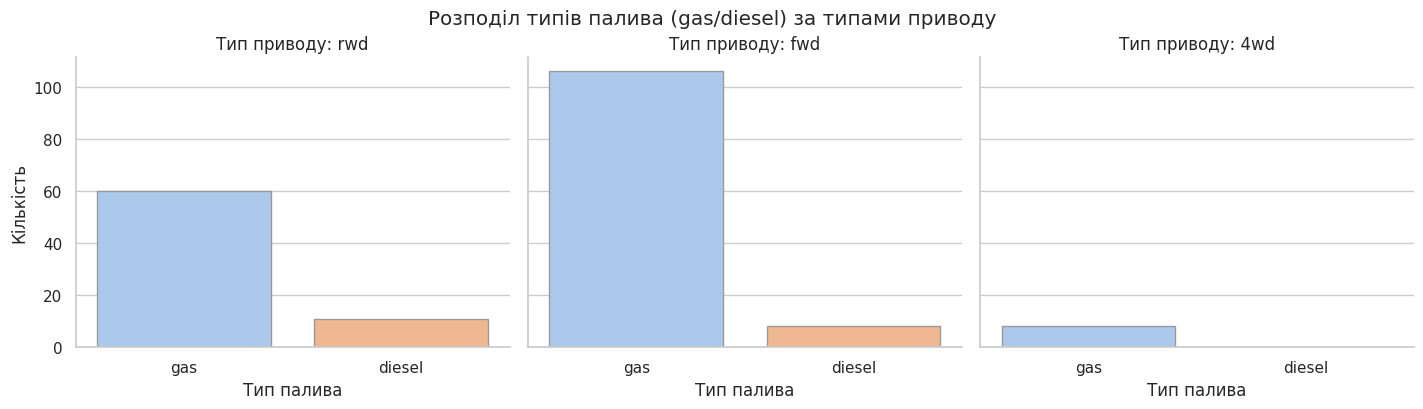

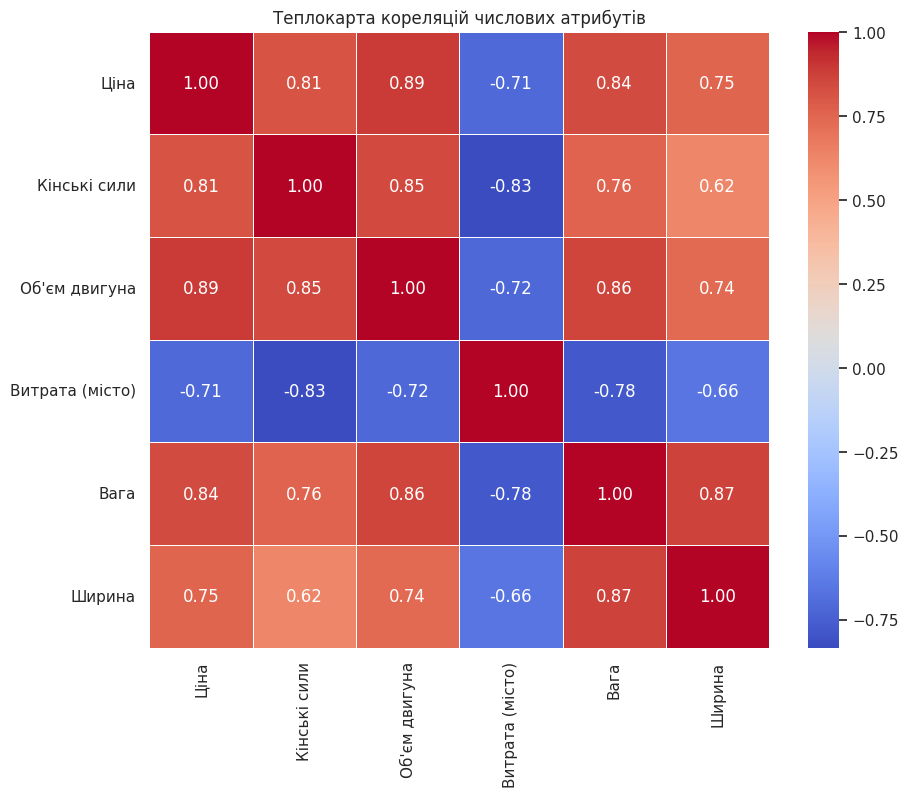

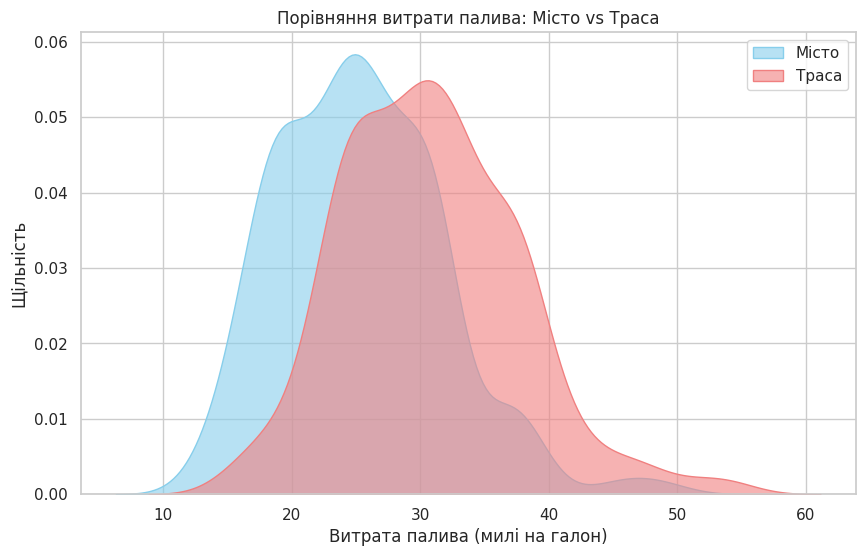

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Фасетований Countplot категоріальних ознак
g = sns.catplot(
    data=df, 
    kind="count", 
    x="fuel-type", 
    col="drive-wheels",  
    hue="fuel-type",     
    palette="pastel",
    edgecolor=".6",
    legend=False,       
    height=4, aspect=1.2
)
g.set_axis_labels("Тип палива", "Кількість")
g.set_titles(col_template="Тип приводу: {col_name}")
g.figure.suptitle("Розподіл типів палива (gas/diesel) за типами приводу", y=1.02)
plt.show()

# Теплокарта кореляцій 
numerical_cols = ['price', 'horsepower', 'engine-size', 'city-mpg', 'curb-weight', 'width']
corr_matrix = df[numerical_cols].corr()
pretty_labels = ['Ціна', 'Кінські сили', "Об'єм двигуна", 'Витрата (місто)', 'Вага', 'Ширина']

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, xticklabels=pretty_labels, yticklabels=pretty_labels)
plt.title("Теплокарта кореляцій числових атрибутів")
plt.show()

# KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="city-mpg", fill=True, label="Місто", color="skyblue", alpha=0.6)
sns.kdeplot(data=df, x="highway-mpg", fill=True, label="Траса", color="lightcoral", alpha=0.6)
plt.title("Порівняння витрати палива: Місто vs Траса")
plt.xlabel("Витрата палива (милі на галон)")
plt.ylabel("Щільність")
plt.legend()
plt.show()